In [1]:
%reload_ext autoreload
%autoreload 2

# TV-timeout classifier — auto-claude experiments

Each section below is one experiment (`vN`). For each: classify, score, plot
the stacked TP/FP/FN histogram + the confusion-matrix heatmap, then write
one summary line to `RESULTS`.

Goal: F1 ≥ 0.9 on row-by-row match against v3 `Official`/`Official TV`
labels in pre-2017 Q2/Q4, seasons 2013-2016.

In [ ]:
import importlib

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

from kret_matplotlib.UTILS_Matplotlib import UTILS_Plotting as UKS_MPL

from nba_timeout_impact.datasets.memo_nbastatsv3 import NBAMemoDF
from nba_timeout_impact.data_pipes import tv_timeout_injection_iterations as it
from nba_timeout_impact.data_pipes.tv_timeout_injection import TVTimeoutValidation
from nba_timeout_impact.plotting_utils.timeout_injection_plots import TimeoutInjectionPlots

SEASONS = (2013, 2016)

memo_v3 = NBAMemoDF.load_all()
# Use the extended prep that keeps personId / teamId / description so the
# v7/v8 structural-signal experiments can run.
v3_pl = it.prep_v3_full(memo_v3, SEASONS)
print(f"v3 rows in 2013-2016: {v3_pl.height:,}")

In [ ]:
RESULTS: list[dict] = []


def run_experiment(name: str, classify_fn, *, widths=(8, 15)):
    """Classify with ``classify_fn``, score row-by-row, plot histogram + heatmap, log."""
    importlib.reload(it)  # pick up any edits to iterations.py
    fn = it.CLASSIFIERS.get(name, classify_fn)
    classified = fn(v3_pl, SEASONS)
    m = it.score(classified, label=name)
    cm = it.confusion(classified)
    print(
        f"{name:25s} TP={m['tp']:5d} FP={m['fp']:5d} FN={m['fn']:5d} "
        f"P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f}"
    )

    # Histogram of TP/FP/FN by sr (uses existing plot helper)
    r_v3 = TVTimeoutValidation._score_row_by_row(classified, seasons=SEASONS, tolerance_s=0, label=name)
    fig, _, _ = TimeoutInjectionPlots.plot_stacked_tp_fp_fn(r_v3, classified, widths=widths)
    # fig.show()

    # Confusion heatmap
    fig_cm, ax_cm = UKS_MPL.subplots(1, 1, width_per=12, height_per=4)
    UKS_MPL.heatmap_df(cm, ax=ax_cm, annot=True, fmt="d", cbar=False)
    ax_cm.set_title(f"{name}: confusion (rows = v3 subType, cols = predicted role)")
    # fig_cm.show()

    RESULTS.append(m)
    return classified, m, fig, fig_cm

# CDNNBA DATASET

# Rulebook-faithful cause classification — comparison vs old heuristic

Previously the cdnnba `timeout_cause` column used `sr ∈ [trigger - 60, trigger]` + `timeout_duration_s ≥ 150s` as a heuristic, plus a separate `coach_preempt` bucket for `sr ∈ (trigger, trigger + 30]`.

**New rule**: for each mandatory-qualified TO, let `K = cumMandatoryPeriod` (its 1-indexed rank among mandatory TOs in the same period). The slot fires at `trigger_K` (post-2017 regulation: `[420, 180]`):

- `sr ≤ trigger_K` → `tv_mandatory` (first dead ball at/after the trigger)
- `sr  > trigger_K` → `coach_absorb` (coach called before the trigger expired)

No duration filter, no sr buffer, no `coach_preempt` sub-bucket. The slot identity comes from the cum count, not from sr range — which matters because the OLD rule called `sr=400, cum_mand=2` rows `tv_mandatory` even though slot 2's trigger is at sr=180, so a slot-2 absorber at sr=400 belongs in `coach_absorb`.

Snapshot of the old categorization (taken right before the refactor) lives at `Notebooks/data-validation/snapshots/causes_before_rulebook.parquet`.

In [ ]:
from pathlib import Path

import polars as pl

from nba_timeout_impact.datasets.enriched_cdnnba import CDNNBADatasetPL

SNAPSHOT_PATH = Path("snapshots/causes_before_rulebook.parquet")

# Old snapshot
old = pl.read_parquet(SNAPSHOT_PATH)
# Re-load the dataset with the NEW (rulebook-faithful) classifier
ds = CDNNBADatasetPL.load_from_parquet()
new = ds.filter(pl.col("actionType") == "timeout").select(
    "gameId",
    "orderNumber",
    "period",
    "seconds_remaining",
    "qualifiers",
    "timeout_duration_s",
    "cumTimeoutsPeriod",
    "timeout_role",
    "timeout_cause",
)

print(f"old (snapshot): {old.height:,} TO rows")
print(f"new (loader):   {new.height:,} TO rows")
print(f"match:          {old.height == new.height}")

Validating cdnnba data (Polars)...
  Passed (4,168,786 rows, 78 cols, 1 warnings).
old (snapshot): 82,197 TO rows
new (loader):   82,197 TO rows
match:          True


In [ ]:
# Cause distributions, old vs new
import pandas as pd

old_counts = (
    old["timeout_cause"].value_counts().sort("count", descending=True).to_pandas().set_index("timeout_cause")["count"]
)
new_counts = (
    new["timeout_cause"].value_counts().sort("count", descending=True).to_pandas().set_index("timeout_cause")["count"]
)
side_by_side = pd.DataFrame({"old": old_counts, "new": new_counts}).fillna(0).astype(int)
side_by_side["delta"] = side_by_side["new"] - side_by_side["old"]
print(side_by_side.to_string())

                       old    new  delta
timeout_cause                           
challenge             1555   1555      0
coach_absorb         32657  39382   6725
coach_discretionary  23747  23747      0
coach_preempt         6344      0  -6344
tv_mandatory         17894  17513   -381


In [ ]:
# Row-by-row crosstab: cause_old × cause_new
combined = (
    old.rename({"timeout_cause": "cause_old"})
    .join(new.select("gameId", "orderNumber", "timeout_cause"), on=["gameId", "orderNumber"], how="inner")
    .rename({"timeout_cause": "cause_new"})
)
ct = pd.crosstab(
    combined["cause_old"].to_pandas(),
    combined["cause_new"].to_pandas(),
    margins=True,
    margins_name="TOTAL",
)
print(ct.to_string())

cause_new            challenge  coach_absorb  coach_discretionary  tv_mandatory  TOTAL
cause_old                                                                             
challenge                 1555             0                    0             0   1555
coach_absorb                 0         30143                    0          2514  32657
coach_discretionary          0             0                23747             0  23747
coach_preempt                0          6322                    0            22   6344
tv_mandatory                 0          2917                    0         14977  17894
TOTAL                     1555         39382                23747         17513  82197


### Side-by-side: TV-mandatory sr distributions, OLD vs NEW

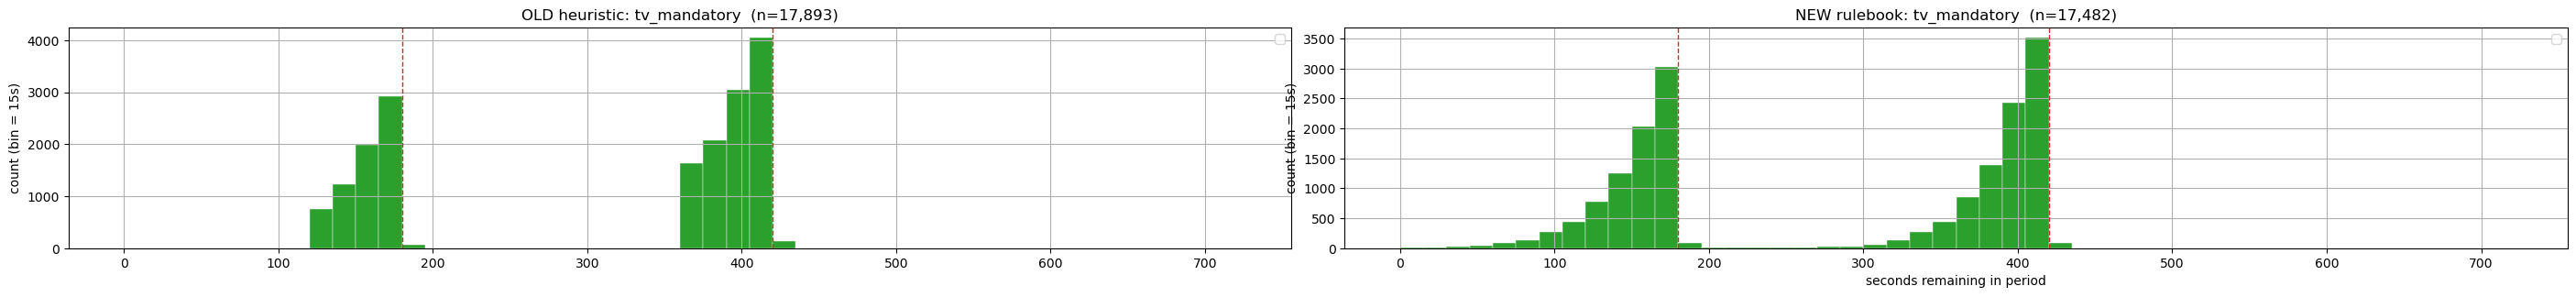

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from kret_matplotlib.UTILS_Matplotlib import UTILS_Plotting as UKS_MPL

# Filter both to tv_mandatory in regulation periods
old_tv = old.filter((pl.col("timeout_cause") == "tv_mandatory") & pl.col("period").is_in([1, 2, 3, 4]))[
    "seconds_remaining"
].to_numpy()
new_tv = new.filter((pl.col("timeout_cause") == "tv_mandatory") & pl.col("period").is_in([1, 2, 3, 4]))[
    "seconds_remaining"
].to_numpy()

fig, axes = UKS_MPL.subplots(2, 1, width_per=14, height_per=3, sharex=True)
bins = np.arange(0, 720 + 15, 15)
axes[0].hist(old_tv, bins=bins, color="tab:green", edgecolor="white", linewidth=0.3)
axes[0].set_title(f"OLD heuristic: tv_mandatory  (n={len(old_tv):,})")
axes[0].set_ylabel("count (bin = 15s)")
axes[1].hist(new_tv, bins=bins, color="tab:green", edgecolor="white", linewidth=0.3)
axes[1].set_title(f"NEW rulebook: tv_mandatory  (n={len(new_tv):,})")
axes[1].set_ylabel("count (bin = 15s)")
axes[1].set_xlabel("seconds remaining in period")
for ax in axes:
    for x in (420, 180):
        ax.axvline(x, color="tab:red", linestyle="--", linewidth=1)
fig

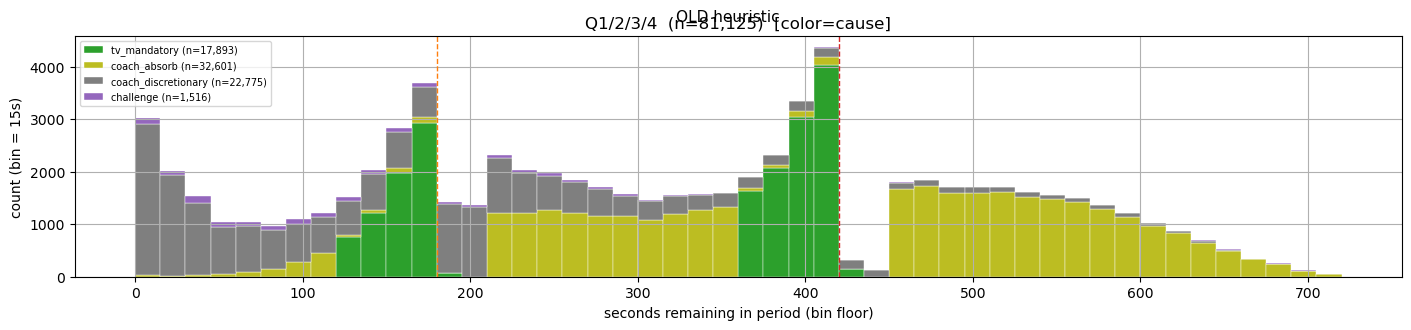

In [ ]:
# Full role_vs_sr plots, coloured by cause, OLD vs NEW
from nba_timeout_impact.plotting_utils.timeout_injection_plots import TimeoutInjectionPlots

# To render an "old-classification" plot from the snapshot we build a polars
# frame that the plotter can consume (it expects actionType + timeout_role
# + timeout_cause columns).
old_full = old.with_columns(pl.lit("timeout").alias("actionType"))
fig_old, _ = TimeoutInjectionPlots.plot_role_vs_sr(old_full, combine_periods=True, color_by="cause")
fig_old.suptitle("OLD heuristic", y=1.02, fontsize=11)
fig_old

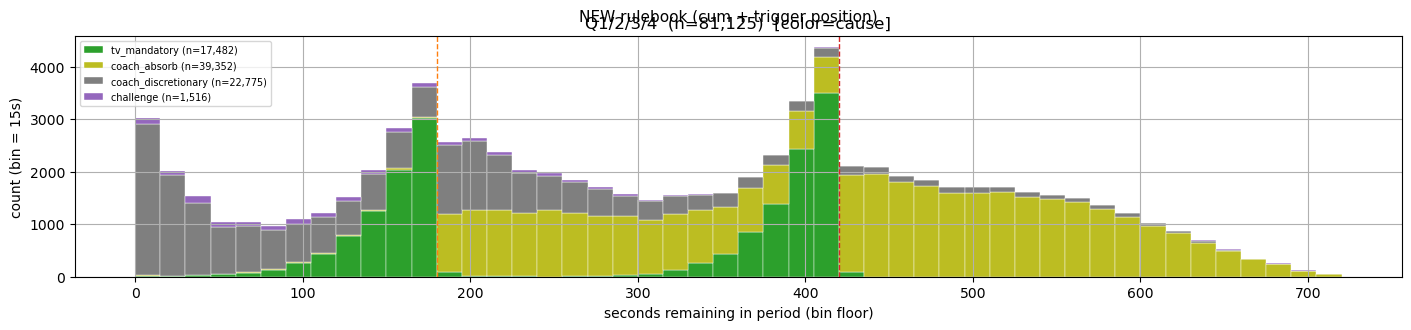

In [ ]:
fig_new, _ = TimeoutInjectionPlots.plot_role_vs_sr(ds, combine_periods=True, color_by="cause")
fig_new.suptitle("NEW rulebook (cum + trigger position)", y=1.02, fontsize=11)
fig_new

### Recommendation

**Keep the new rulebook-faithful approach.** Three reasons:

1. **No arbitrary cutoffs.** The OLD rule had three tunable constants (`TV_BREAK_SR_BUFFER_S=60`, `TV_BREAK_DURATION_MIN_S=150`, `COACH_PREEMPT_SR_BUFFER_S=30`) that were judgment calls. The NEW rule has zero — slot K is determined by `cumMandatoryPeriod` and the rulebook triggers.

2. **Fixes the slot-2 misclassification.** 2,917 rows flipped from OLD `tv_mandatory` → NEW `coach_absorb`. These are mandatory-qualified TOs at sr≈400 with `cum_mand=2`. The OLD rule called them TV breaks because they sit in slot 1's sr window; the rulebook says they're filling slot 2 (next mandatory firing at sr=180) so they're coach absorbs, not auto-fires.

3. **Cleaner taxonomy.** 4 categories instead of 5 (`coach_preempt` is gone — it was an arbitrary 30s carve-out from `coach_absorb` with no rulebook basis).

### Trade-off to know about

The new `tv_mandatory` includes some events that *aren't* full TV breaks — e.g., late slot 1 firings (no dead ball between sr=420 and sr=200, so the league's mandatory fires at sr=200 instead of right after the trigger). The OLD rule's duration filter excluded those. If your causal analysis needs **only events that took a real broadcast break**, layer the duration filter on top:

```python
tv_breaks = ds.filter(
    (pl.col("timeout_cause") == "tv_mandatory")
    & (pl.col("timeout_duration_s") >= 150)
)
```

That gives you the strict "TV-break" subset (≈15,000 events) while leaving `timeout_cause` itself rulebook-clean.